# Phase 2 comparison -- June-Aug (unfiltered/filtered) vs. Sept-Nov (filtered)

**Run this only after `code_phase2_harbin_unfiltered.ipynb`, `code_phase2_harbin_filtered.ipynb`, and `code_phase2_harbin_sepnov.ipynb` have all finished training and saved their models to Drive.** This notebook is fully self-contained (its own Drive mount, its own extraction of all three datasets, its own model loading) -- it doesn't depend on any training notebook's session state, so it's safe to run in a completely fresh Colab runtime.

**What's being compared, and why the statistical test differs between the two comparisons here** -- this notebook makes two genuinely different kinds of comparison, and treats them differently on purpose:

1. **Unfiltered vs. filtered (June-Aug)**: both share the identical 917/211/184 train/val/test split (same underlying images, same acquisition dates, only the mask-generation rule differs). Every validation image has an unfiltered-model prediction *and* a filtered-model prediction on the exact same input -- a genuine paired design, so the paired Wilcoxon signed-rank test used in `code_phase2_harbin_comparison.ipynb` is appropriate here too (reproduced below for completeness).

2. **Filtered June-Aug vs. Sept-Nov**: these come from *different acquisition windows* -- different dates, and not even guaranteed to be the same tile positions after the independent 70/15/15 hash-split each dataset went through. There is no shared validation image to pair predictions on, so treating this like (1) with a paired test would be invalid (Wilcoxon assumes the two samples are matched pairs of the same underlying unit). Instead this uses an **unpaired Mann-Whitney U test** (`scipy.stats.mannwhitneyu`) on the two independent per-image accuracy distributions -- non-parametric for the same reason as before (per-image accuracy is a bounded, skewed proportion, not normally distributed), but appropriate for two independent samples rather than matched pairs.

In [ ]:
import os
# Force legacy Keras 2 behaviour. Current TF ships Keras 3 by default, which
# breaks this codebase's private optimizer-internals usage and the
# unmaintained `segmentation_models` package -- tf_keras is TF's official
# compatibility shim for exactly this situation, same fix already applied
# in predictor.py.
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import sys
import numpy as np
import pandas as pd
import PIL
import requests
import tensorflow as tf
import tf_keras as keras
from tf_keras.models import *
from tf_keras.layers import *
from tf_keras.optimizers import *
from tf_keras.losses import *
from tf_keras import backend as K
from tf_keras.callbacks import ModelCheckpoint
from tf_keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import *


In [ ]:
# Colab setup: mount Drive, clone the repo, extract all THREE ground-truth
# archives, and locate all three trained models (copied to Drive at the
# end of each training notebook).
import os
import shutil

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

VERSIONS = ("unfiltered", "filtered", "sepnov")
MODEL_FILENAMES = {
    "unfiltered": "unet-attention-4d-harbin-unfiltered.hdf5",
    "filtered": "unet-attention-4d-harbin-filtered.hdf5",
    "sepnov": "unet-attention-4d-harbin-sepnov.hdf5",
}

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

    REPO_DIR = "/content/COMP0173_poster_pre"
    if not os.path.exists(REPO_DIR):
        !git clone -q https://github.com/jy-gfm/COMP0173_poster_pre.git {REPO_DIR}
    os.chdir(REPO_DIR)

    DRIVE_DIR = "/content/drive/MyDrive/COMP0173/"
    DATA_DIRS = {}
    MODEL_PATHS = {}

    for version in VERSIONS:
        tar_name = f"Haerbing_ground_truth_{version}"
        local_data_dir = f"/content/{tar_name}"
        if not os.path.exists(local_data_dir):
            extract_root = f"/content/{tar_name}_extract"
            os.makedirs(extract_root, exist_ok=True)
            !tar -xf {DRIVE_DIR}{tar_name}.tar -C {extract_root} 2>&1 | grep -v "Ignoring unknown extended header keyword" || true
            local_data_dir = f"{extract_root}/{tar_name}"
        DATA_DIRS[version] = local_data_dir

        local_model_path = f"/content/{MODEL_FILENAMES[version]}"
        if not os.path.exists(local_model_path):
            shutil.copy(f"{DRIVE_DIR}{MODEL_FILENAMES[version]}", local_model_path)
        MODEL_PATHS[version] = local_model_path
else:
    DATA_DIRS = {v: f"./Haerbing_ground_truth_{v}" for v in VERSIONS}
    MODEL_PATHS = {v: MODEL_FILENAMES[v] for v in VERSIONS}

print("DATA_DIRS:", DATA_DIRS)
print("MODEL_PATHS:", MODEL_PATHS)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DATA_DIRS: {'unfiltered': '/content/Haerbing_ground_truth_unfiltered_extract/Haerbing_ground_truth_unfiltered', 'filtered': '/content/Haerbing_ground_truth_filtered_extract/Haerbing_ground_truth_filtered', 'sepnov': '/content/Haerbing_ground_truth_sepnov_extract/Haerbing_ground_truth_sepnov'}
MODEL_PATHS: {'unfiltered': '/content/unet-attention-4d-harbin-unfiltered.hdf5', 'filtered': '/content/unet-attention-4d-harbin-filtered.hdf5', 'sepnov': '/content/unet-attention-4d-harbin-sepnov.hdf5'}


In [ ]:
!ls /content/*.tar 2>/dev/null
!du -sh /content/Haerbing_ground_truth_* 2>/dev/null


5.5G	/content/Haerbing_ground_truth_filtered_extract
7.4G	/content/Haerbing_ground_truth_sepnov_extract
5.5G	/content/Haerbing_ground_truth_unfiltered_extract


## Load all three models and compute per-image validation accuracy for each

In [ ]:
import numpy as np
import glob
from scipy.stats import wilcoxon, mannwhitneyu

def load_validation(version):
    paths = sorted(glob.glob(f"{DATA_DIRS[version]}/validation/images/*.npy"))
    images = [np.load(p).reshape(1, 512, 512, 4) for p in paths]
    masks = [np.load(p.replace("/images/", "/masks/")).reshape(1, 512, 512, 1) for p in paths]
    return paths, images, masks

def per_image_accuracy(model, images, masks):
    scores = []
    for img, mask in zip(images, masks):
        pred = np.round(model.predict(img, verbose=0)).flatten()
        scores.append((pred == mask.flatten()).mean())
    return np.array(scores)

models = {v: keras.models.load_model(MODEL_PATHS[v], compile=False) for v in VERSIONS}

paths, images, masks, acc = {}, {}, {}, {}
for v in VERSIONS:
    paths[v], images[v], masks[v] = load_validation(v)
    acc[v] = per_image_accuracy(models[v], images[v], masks[v])
    print(f"{v}: n={len(acc[v])}, mean per-image accuracy = {acc[v].mean():.4f} (+/- {acc[v].std():.4f})")


unfiltered: n=211, mean per-image accuracy = 0.8982 (+/- 0.1339)
filtered: n=211, mean per-image accuracy = 0.9141 (+/- 0.1309)
sepnov: n=273, mean per-image accuracy = 0.9798 (+/- 0.0215)


## Visual sanity check -- is the sepnov improvement genuine forest detection?

The Sept-Nov model's accuracy jump (0.9141 -> 0.9798 mean per-image, p=1.24e-31) is large enough
to deserve a direct look before trusting it: is this genuine forest-boundary detection, or does
the task just become spectrally trivial post-harvest (bare fields vs. forest) in a way that would
make almost any method look good? Plotting predictions against ground truth on the worst-, best-,
and two typical-scoring validation images checks this directly, and doubles as the failure case
analysis for the Sept-Nov model.

In [ ]:
def stretch_for_display(rgb, low_pct=2, high_pct=98, gamma=0.6):
    stretched = np.zeros_like(rgb)
    for c in range(rgb.shape[-1]):
        band = rgb[:, :, c]
        lo, hi = np.percentile(band, [low_pct, high_pct])
        stretched[:, :, c] = np.clip((band - lo) / max(hi - lo, 1e-6), 0, 1)
    return np.clip(stretched, 0, 1) ** gamma


def show_prediction_examples(version, indices, titles):
    fig, axes = plt.subplots(3, len(indices), figsize=(4.5 * len(indices), 12))
    for col, (idx, title) in enumerate(zip(indices, titles)):
        img = images[version][idx][0]          # (512, 512, 4)
        mask = masks[version][idx][0, :, :, 0]  # (512, 512)
        pred = np.round(models[version].predict(images[version][idx], verbose=0))[0, :, :, 0]

        axes[0, col].imshow(stretch_for_display(img[:, :, :3]))
        axes[0, col].set_title(f"{title}\nacc={acc[version][idx]:.3f}")
        axes[0, col].axis("off")

        axes[1, col].imshow(mask, cmap="Greens", vmin=0, vmax=1)
        axes[1, col].set_title("ground truth")
        axes[1, col].axis("off")

        axes[2, col].imshow(pred, cmap="Greens", vmin=0, vmax=1)
        axes[2, col].set_title("model prediction")
        axes[2, col].axis("off")
    plt.tight_layout()
    plt.show()


sepnov_acc = acc["sepnov"]
worst_idx = int(np.argmin(sepnov_acc))
best_idx = int(np.argmax(sepnov_acc))
rng = np.random.RandomState(0)
random_idxs = rng.choice(
    [i for i in range(len(sepnov_acc)) if i not in (worst_idx, best_idx)], size=2, replace=False
)

show_prediction_examples(
    "sepnov",
    indices=[worst_idx] + list(random_idxs) + [best_idx],
    titles=["worst case", "typical", "typical", "best case"],
)

## Comparison 1 (paired) -- unfiltered vs. filtered, June-Aug

In [ ]:
# Sanity check: same underlying positions in the same order in both datasets
assert [os.path.basename(p) for p in paths["unfiltered"]] == [os.path.basename(p) for p in paths["filtered"]], \
    "unfiltered/filtered validation sets don't line up -- can't pair them"

stat_uf, p_uf = wilcoxon(acc["unfiltered"], acc["filtered"])
print(f"Wilcoxon signed-rank test (unfiltered vs. filtered): statistic={stat_uf:.2f}, p-value={p_uf:.4g}")
print("Statistically significant at alpha=0.05." if p_uf < 0.05 else "Not statistically significant at alpha=0.05.")


Wilcoxon signed-rank test (unfiltered vs. filtered): statistic=5671.00, p-value=5.374e-10
Statistically significant at alpha=0.05.


## Comparison 2 (unpaired) -- filtered June-Aug vs. Sept-Nov

Different images, different acquisition dates, independently split -- so this uses the unpaired Mann-Whitney U test on the two accuracy distributions rather than pairing by position (see this notebook's opening cell for why).

In [ ]:
stat_season, p_season = mannwhitneyu(acc["filtered"], acc["sepnov"], alternative="two-sided")
print(f"Mann-Whitney U test (filtered June-Aug vs. Sept-Nov): statistic={stat_season:.2f}, p-value={p_season:.4g}")
print("Statistically significant at alpha=0.05." if p_season < 0.05 else "Not statistically significant at alpha=0.05.")

better_season = "Sept-Nov" if acc["sepnov"].mean() > acc["filtered"].mean() else "June-Aug"
print(f"\nHigher mean per-image accuracy: {better_season} "
      f"(June-Aug filtered={acc['filtered'].mean():.4f}, Sept-Nov={acc['sepnov'].mean():.4f})")


Mann-Whitney U test (filtered June-Aug vs. Sept-Nov): statistic=10945.50, p-value=1.241e-31
Statistically significant at alpha=0.05.

Higher mean per-image accuracy: Sept-Nov (June-Aug filtered=0.9141, Sept-Nov=0.9798)


## Visualize all three

/tmp/ipykernel_2575/1636582199.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([acc["unfiltered"], acc["filtered"], acc["sepnov"]], labels=labels)


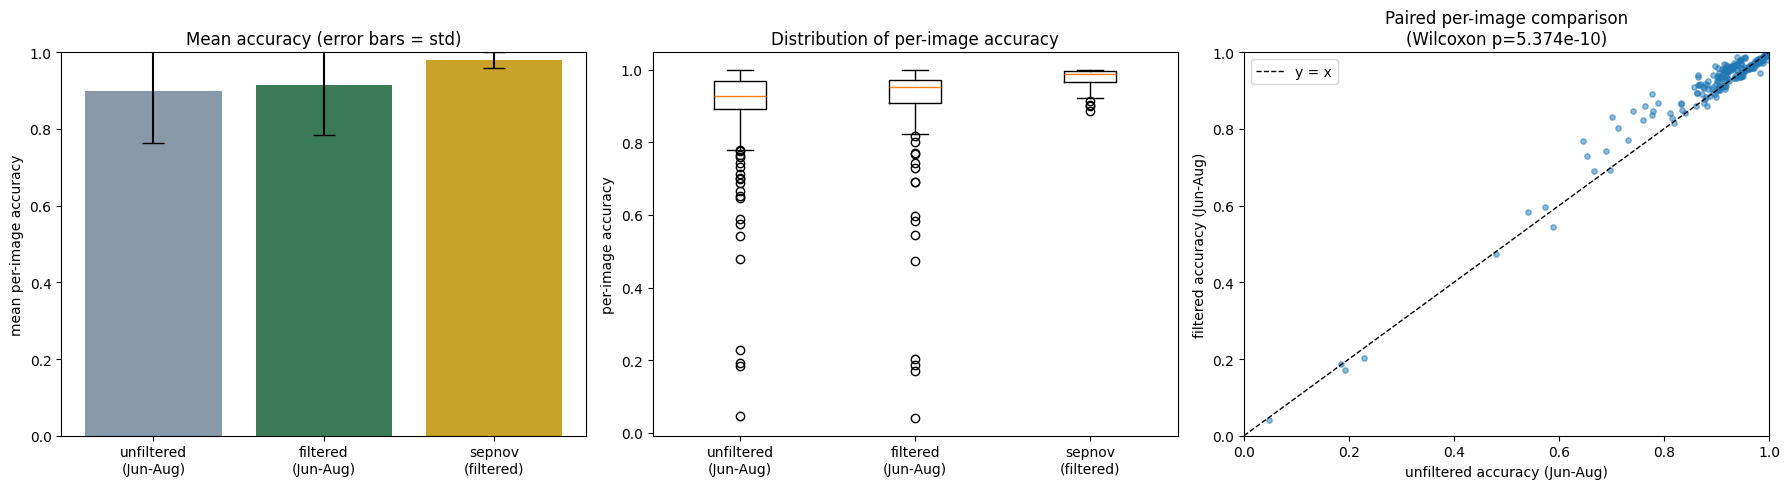

unfiltered: 0.8982 +/- 0.1339 (n=211)
filtered: 0.9141 +/- 0.1309 (n=211)
sepnov: 0.9798 +/- 0.0215 (n=273)


In [ ]:
import matplotlib.pyplot as plt

labels = ["unfiltered\n(Jun-Aug)", "filtered\n(Jun-Aug)", "sepnov\n(filtered)"]
colors = ["#8899AA", "#3B7A57", "#C9A227"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Mean accuracy with std error bars, all three models
means = [acc["unfiltered"].mean(), acc["filtered"].mean(), acc["sepnov"].mean()]
stds = [acc["unfiltered"].std(), acc["filtered"].std(), acc["sepnov"].std()]
axes[0].bar(labels, means, yerr=stds, capsize=8, color=colors)
axes[0].set_ylabel("mean per-image accuracy")
axes[0].set_title("Mean accuracy (error bars = std)")
axes[0].set_ylim(0, 1)

# 2. Full distribution of per-image accuracy, all three models
axes[1].boxplot([acc["unfiltered"], acc["filtered"], acc["sepnov"]], labels=labels)
axes[1].set_ylabel("per-image accuracy")
axes[1].set_title("Distribution of per-image accuracy")

# 3. Paired scatter -- ONLY for the genuinely paired comparison
# (unfiltered vs. filtered, same validation images). No equivalent plot
# for sepnov since it has no shared images to pair against.
lims = [0, 1]
axes[2].plot(lims, lims, 'k--', linewidth=1, label="y = x")
axes[2].scatter(acc["unfiltered"], acc["filtered"], alpha=0.5, s=15)
axes[2].set_xlabel("unfiltered accuracy (Jun-Aug)")
axes[2].set_ylabel("filtered accuracy (Jun-Aug)")
axes[2].set_title(f"Paired per-image comparison\n(Wilcoxon p={p_uf:.4g})")
axes[2].legend()
axes[2].set_xlim(lims)
axes[2].set_ylim(lims)

plt.tight_layout()
plt.show()

for v in VERSIONS:
    print(f"{v}: {acc[v].mean():.4f} +/- {acc[v].std():.4f} (n={len(acc[v])})")


## Overfitting check -- train vs. validation accuracy per model

Separate from the label-circularity concern (section 8 of `poster_notes.md`):
this checks classic overfitting (train/val gap), not whether the label
itself is too easy to learn. A model can show zero overfitting here and
still suffer from label circularity -- they're independent failure modes.

In [ ]:
import matplotlib.pyplot as plt

HISTORY_FILENAMES = {v: MODEL_FILENAMES[v].replace(".hdf5", "-history.npy") for v in VERSIONS}

histories = {}
for version in VERSIONS:
    local_path = f"/content/{HISTORY_FILENAMES[version]}"
    if IN_COLAB and not os.path.exists(local_path):
        shutil.copy(f"{DRIVE_DIR}{HISTORY_FILENAMES[version]}", local_path)
    else:
        local_path = HISTORY_FILENAMES[version]
    histories[version] = np.load(local_path, allow_pickle=True).item()

fig, axes = plt.subplots(1, len(VERSIONS), figsize=(5 * len(VERSIONS), 4), sharey=True)
for ax, version in zip(axes, VERSIONS):
    h = histories[version]
    ax.plot(h["accuracy"], label="train")
    ax.plot(h["val_accuracy"], label="validation")
    ax.set_title(version)
    ax.set_xlabel("epoch")
    ax.legend()
axes[0].set_ylabel("accuracy")
plt.tight_layout()
plt.show()

# A train/val gap growing over epochs is classic overfitting -- the model
# fitting training-set specifics that don't hold on held-out validation
# tiles. A small, stable gap across epochs is normal and not a concern.
print("Final-epoch train vs. validation accuracy gap (overfitting check):")
for version in VERSIONS:
    h = histories[version]
    train_acc = h["accuracy"][-1]
    val_acc = h["val_accuracy"][-1]
    gap = train_acc - val_acc
    flag = "  <-- possible overfitting" if gap > 0.05 else ""
    print(f"  {version}: train={train_acc:.4f}, val={val_acc:.4f}, gap={gap:+.4f}{flag}")

In [11]:
!git -C /content/COMP0173_poster_pre pull


remote: Enumerating objects: 13, done.
remote: Counting objects: 100% (12/12), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 9 (delta 5), reused 7 (delta 4), pack-reused 0 (from 0)
Unpacking objects: 100% (9/9), 81.64 KiB | 3.40 MiB/s, done.
From https://github.com/jy-gfm/COMP0173_poster_pre
   b600b05..b26a167  main       -> origin/main
Updating b600b05..b26a167
Fast-forward
 code_phase2_harbin_comparison_sepnov.ipynb | 246 ++++++++++++++++++++++++++---
 1 file changed, 225 insertions(+), 21 deletions(-)


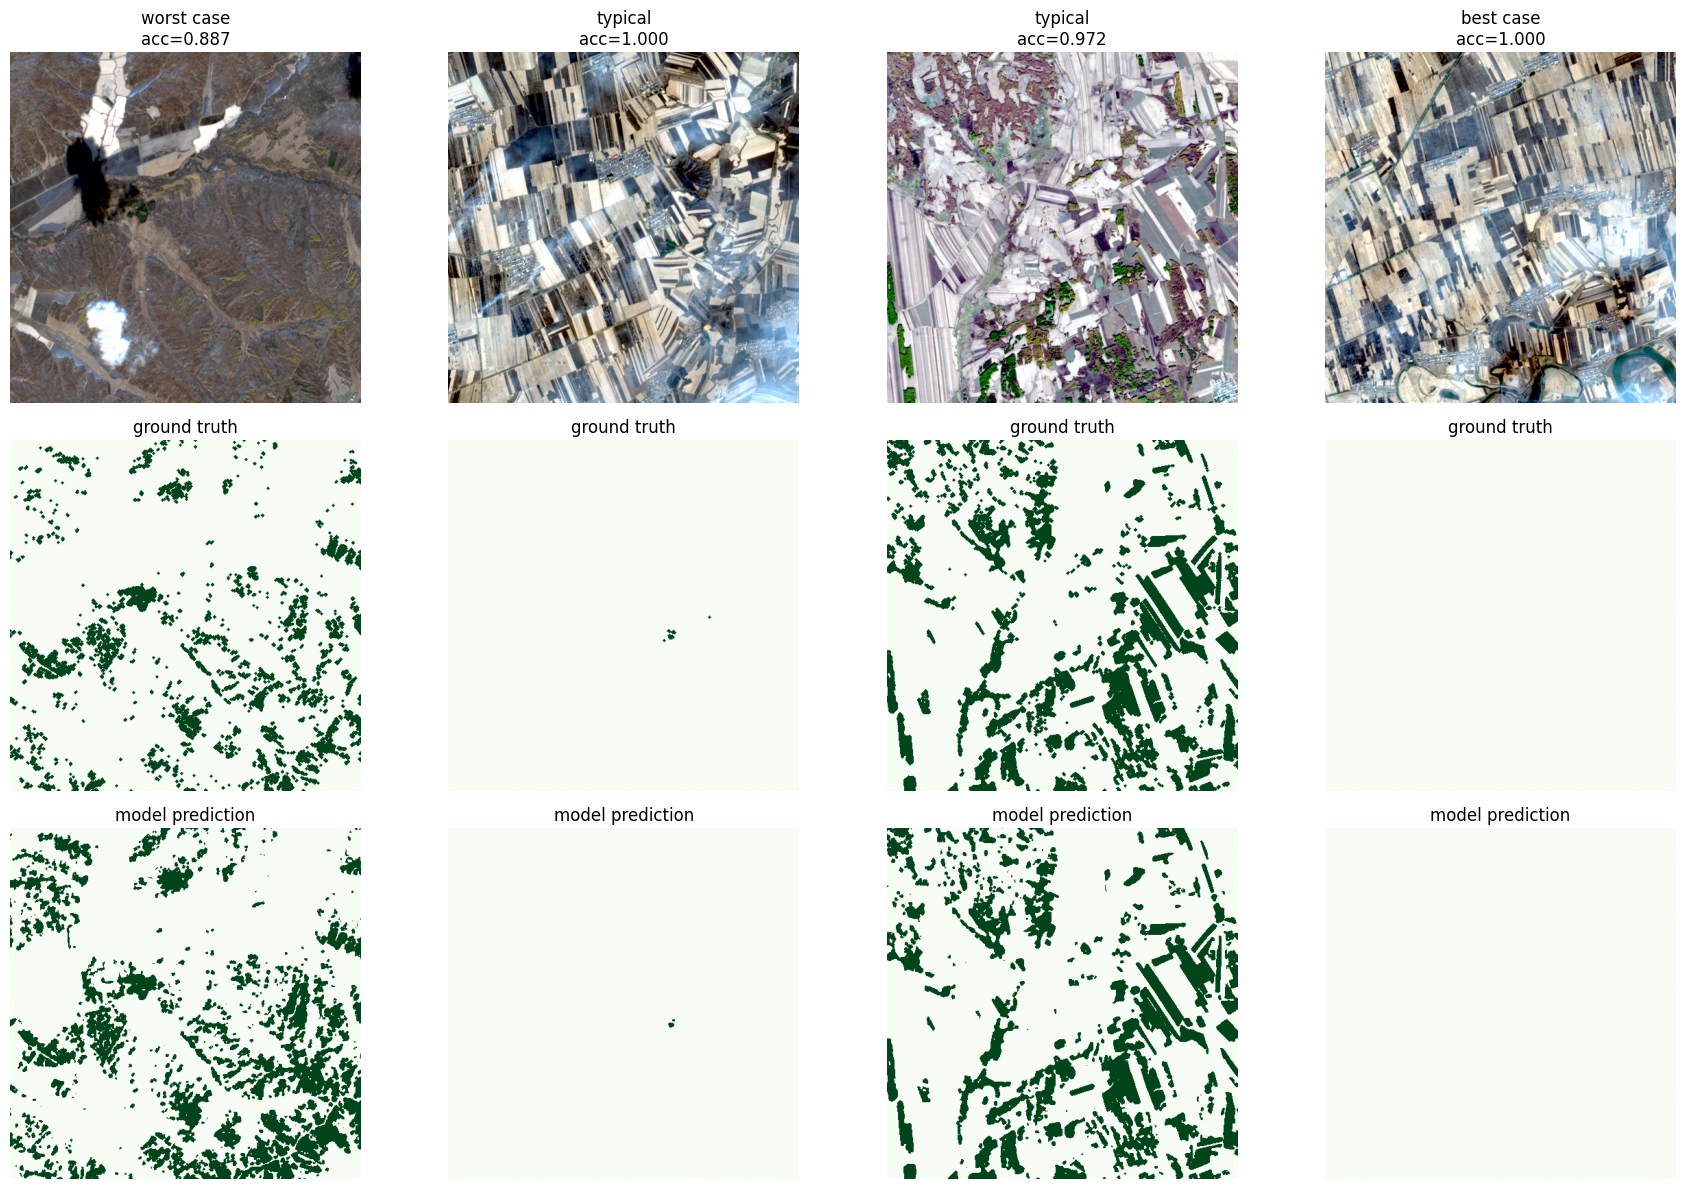

In [12]:
def stretch_for_display(rgb, low_pct=2, high_pct=98, gamma=0.6):
    stretched = np.zeros_like(rgb)
    for c in range(rgb.shape[-1]):
        band = rgb[:, :, c]
        lo, hi = np.percentile(band, [low_pct, high_pct])
        stretched[:, :, c] = np.clip((band - lo) / max(hi - lo, 1e-6), 0, 1)
    return np.clip(stretched, 0, 1) ** gamma


def show_prediction_examples(version, indices, titles):
    fig, axes = plt.subplots(3, len(indices), figsize=(4.5 * len(indices), 12))
    for col, (idx, title) in enumerate(zip(indices, titles)):
        img = images[version][idx][0]          # (512, 512, 4)
        mask = masks[version][idx][0, :, :, 0]  # (512, 512)
        pred = np.round(models[version].predict(images[version][idx], verbose=0))[0, :, :, 0]

        axes[0, col].imshow(stretch_for_display(img[:, :, :3]))
        axes[0, col].set_title(f"{title}\nacc={acc[version][idx]:.3f}")
        axes[0, col].axis("off")

        axes[1, col].imshow(mask, cmap="Greens", vmin=0, vmax=1)
        axes[1, col].set_title("ground truth")
        axes[1, col].axis("off")

        axes[2, col].imshow(pred, cmap="Greens", vmin=0, vmax=1)
        axes[2, col].set_title("model prediction")
        axes[2, col].axis("off")
    plt.tight_layout()
    plt.show()


sepnov_acc = acc["sepnov"]
worst_idx = int(np.argmin(sepnov_acc))
best_idx = int(np.argmax(sepnov_acc))
rng = np.random.RandomState(0)
random_idxs = rng.choice(
    [i for i in range(len(sepnov_acc)) if i not in (worst_idx, best_idx)], size=2, replace=False
)

show_prediction_examples(
    "sepnov",
    indices=[worst_idx] + list(random_idxs) + [best_idx],
    titles=["worst case", "typical", "typical", "best case"],
)
